# Imports

In [14]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Sklearn
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)
from collections import Counter
from imblearn.over_sampling import SMOTE

# XGBoost
import xgboost as xgb
print(f"XGBoost version : {xgb.__version__}")

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Device — XGBoost uses GPU via tree_method
import subprocess
try:
    subprocess.check_output('nvidia-smi')
    DEVICE = 'cuda'
except:
    DEVICE = 'cpu'
print(f"Device          : {DEVICE}")

XGBoost version : 3.2.0
Device          : cuda


# Dataset

In [15]:
DATA_DIR = './cic_ids_2017/'
LABEL_COL = 'Label'


csv_files = [
    'Monday-WorkingHours.pcap_ISCX.csv',
    'Tuesday-WorkingHours.pcap_ISCX.csv',
    'Wednesday-workingHours.pcap_ISCX.csv',
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
]

dfs = []
for f in csv_files:
    path = os.path.join(DATA_DIR, f)
    if os.path.exists(path):
        df_tmp = pd.read_csv(path, encoding='utf-8', low_memory=False)
        dfs.append(df_tmp)
        print(f"Loaded  {f:60s}| rows: {len(df_tmp):>8,}")
    else:
        print(f"[SKIP]  File not found: {path}")

df = pd.concat(dfs, ignore_index=True)
print(f"\nTotal rows : {len(df):,}  |  Columns : {df.shape[1]}")

Loaded  Monday-WorkingHours.pcap_ISCX.csv                           | rows:  529,918
Loaded  Tuesday-WorkingHours.pcap_ISCX.csv                          | rows:  445,909
Loaded  Wednesday-workingHours.pcap_ISCX.csv                        | rows:  692,703
Loaded  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv      | rows:  170,366
Loaded  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv | rows:  288,602
Loaded  Friday-WorkingHours-Morning.pcap_ISCX.csv                   | rows:  191,033
Loaded  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv        | rows:  286,467
Loaded  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv            | rows:  225,745

Total rows : 2,830,743  |  Columns : 79


# Preprocessing

In [ ]:
df.head(20)

In [ ]:
df.describe()

In [ ]:
print(df.columns)


In [ ]:
print(df.shape)

In [16]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
print(df.columns)


Index(['Destination_Port', 'Flow_Duration', 'Total_Fwd_Packets',
       'Total_Backward_Packets', 'Total_Length_of_Fwd_Packets',
       'Total_Length_of_Bwd_Packets', 'Fwd_Packet_Length_Max',
       'Fwd_Packet_Length_Min', 'Fwd_Packet_Length_Mean',
       'Fwd_Packet_Length_Std', 'Bwd_Packet_Length_Max',
       'Bwd_Packet_Length_Min', 'Bwd_Packet_Length_Mean',
       'Bwd_Packet_Length_Std', 'Flow_Bytes/s', 'Flow_Packets/s',
       'Flow_IAT_Mean', 'Flow_IAT_Std', 'Flow_IAT_Max', 'Flow_IAT_Min',
       'Fwd_IAT_Total', 'Fwd_IAT_Mean', 'Fwd_IAT_Std', 'Fwd_IAT_Max',
       'Fwd_IAT_Min', 'Bwd_IAT_Total', 'Bwd_IAT_Mean', 'Bwd_IAT_Std',
       'Bwd_IAT_Max', 'Bwd_IAT_Min', 'Fwd_PSH_Flags', 'Bwd_PSH_Flags',
       'Fwd_URG_Flags', 'Bwd_URG_Flags', 'Fwd_Header_Length',
       'Bwd_Header_Length', 'Fwd_Packets/s', 'Bwd_Packets/s',
       'Min_Packet_Length', 'Max_Packet_Length', 'Packet_Length_Mean',
       'Packet_Length_Std', 'Packet_Length_Variance', 'FIN_Flag_Count',
       'SYN_Flag_Co

In [ ]:
df.info()

In [17]:
cols_to_drop = [
    'Fwd_Packet_Length_Max',
    'Fwd_Packet_Length_Min',
    'Fwd_Packet_Length_Std',
    'Bwd_Packet_Length_Max',
    'Bwd_Packet_Length_Min',
    'Bwd_Packet_Length_Mean',
    'Bwd_Packet_Length_Std',
    'Flow_IAT_Std',
    'Flow_IAT_Max',
    'Flow_IAT_Min',
    'Fwd_IAT_Std',
    'Fwd_IAT_Max',
    'Fwd_IAT_Min',
    'Bwd_IAT_Std',
    'Bwd_IAT_Max',
    'Bwd_IAT_Min',
    'Min_Packet_Length',
    'Max_Packet_Length',
    'Packet_Length_Std',
    'Active_Std',
    'Active_Max',
    'Active_Min',
    'Idle_Std',
    'Idle_Max',
    'Idle_Min'
]
df.drop(columns=cols_to_drop, inplace=True)

In [18]:
print(df.shape)

(2830743, 54)


In [ ]:

df.columns = df.columns.str.strip()


df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print(f"After cleaning : {len(df):,} rows")
print(f"Class distribution:\n{df['Label'].value_counts()}")

After cleaning : 2,827,876 rows
Class distribution:
Label
BENIGN                        2271320
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [20]:
rename_classes = {
    'Web Attack � Brute Force' : 'Brute Force',
    'Web Attack � XSS' : 'XSS',
    'Web Attack � Sql Injection' : 'SQL Injection'

}

df[LABEL_COL] = df[LABEL_COL].map(rename_classes).fillna(df[LABEL_COL])
print(df[LABEL_COL].value_counts())

Label
BENIGN              2271320
DoS Hulk             230124
PortScan             158804
DDoS                 128025
DoS GoldenEye         10293
FTP-Patator            7935
SSH-Patator            5897
DoS slowloris          5796
DoS Slowhttptest       5499
Bot                    1956
Brute Force            1507
XSS                     652
Infiltration             36
SQL Injection            21
Heartbleed               11
Name: count, dtype: int64


In [21]:
label_map = {
    'BENIGN': 'Benign Traffic',
    'DoS Hulk': 'DoS Attacks',
    'DoS GoldenEye': 'DoS Attacks',
    'DoS slowloris': 'DoS Attacks',
    'DoS Slowhttptest': 'DoS Attacks',
    'DDoS': 'DDoS Attacks',
    'PortScan': 'Port Scanning & Brute Force',
    'FTP-Patator': 'Port Scanning & Brute Force',
    'SSH-Patator': 'Port Scanning & Brute Force',
    'Brute Force': 'Web-Based Attacks',
    'XSS': 'Web-Based Attacks',
    'SQL Injection': 'Web-Based Attacks',
    'Bot': 'Other Exploits & Infiltrations',
    'Infiltration': 'Other Exploits & Infiltrations',
    'Heartbleed': 'Other Exploits & Infiltrations'
}
df[LABEL_COL] = df[LABEL_COL].map(label_map).fillna(df[LABEL_COL])

print("Consolidated class distribution:")
print(df[LABEL_COL].value_counts())

Consolidated class distribution:
Label
Benign Traffic                    2271320
DoS Attacks                        251712
Port Scanning & Brute Force        172636
DDoS Attacks                       128025
Web-Based Attacks                    2180
Other Exploits & Infiltrations       2003
Name: count, dtype: int64


In [ ]:

le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'].str.strip())

CLASS_NAMES = le.classes_.tolist()
n_classes   = len(CLASS_NAMES)
print(f"Classes ({n_classes}): {CLASS_NAMES}")


X = df.drop(columns=['Label'])
y = df['Label']


X = X.select_dtypes(include=[np.number])
print(f"Feature shape  : {X.shape}")

Classes (6): ['Benign Traffic', 'DDoS Attacks', 'DoS Attacks', 'Other Exploits & Infiltrations', 'Port Scanning & Brute Force', 'Web-Based Attacks']
Feature shape  : (2827876, 53)


In [ ]:
# Train test val split
X_np = X.values.astype(np.float32)
y_np = y.astype(np.int64)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_np, y_np, test_size=0.30, stratify=y_np, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

# 
scaler  = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)
joblib.dump(scaler, 'xgb_scaler.pkl')

print(f"Train : {X_train.shape[0]:,}  Val : {X_val.shape[0]:,}  Test : {X_test.shape[0]:,}")

Train : 1,979,513  Val : 424,181  Test : 424,182


# SMOTE

In [ ]:
print("Before SMOTE:", dict(zip(*np.unique(y_train, return_counts=True))))


min_samples = min(Counter(y_train).values())
k = min(5, min_samples - 1)
print(f"Using k_neighbors = {k}")

sm = SMOTE(random_state=SEED, k_neighbors=k)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("After  SMOTE:", dict(zip(*np.unique(y_train_sm, return_counts=True))))
print(f"Train size after SMOTE : {X_train_sm.shape[0]:,}")

Before SMOTE: {np.int64(0): np.int64(1589924), np.int64(1): np.int64(89618), np.int64(2): np.int64(176198), np.int64(3): np.int64(1402), np.int64(4): np.int64(120845), np.int64(5): np.int64(1526)}
Using k_neighbors = 5
After  SMOTE: {np.int64(0): np.int64(1589924), np.int64(1): np.int64(1589924), np.int64(2): np.int64(1589924), np.int64(3): np.int64(1589924), np.int64(4): np.int64(1589924), np.int64(5): np.int64(1589924)}
Train size after SMOTE : 9,539,544


# XGBoost Model Setup

In [ ]:
# class weight for imbalance
weights    = compute_class_weight('balanced',
                                   classes=np.unique(y_train_sm),
                                   y=y_train_sm)
sample_wts = np.array([weights[c] for c in y_train_sm])
print(f"Class weights computed : {dict(zip(CLASS_NAMES, weights.round(3)))}")

dtrain = xgb.DMatrix(X_train_sm, label=y_train_sm, weight=sample_wts)
dval   = xgb.DMatrix(X_val,      label=y_val)
dtest  = xgb.DMatrix(X_test,     label=y_test)

params = {
    'objective'        : 'multi:softmax',
    'num_class'        : n_classes,
    'eval_metric'      : ['mlogloss', 'merror'],
    'max_depth'        : 8,           # tree depth
    'learning_rate'    : 0.1,         # shrinkage
    'n_estimators'     : 500,         # max boosting rounds
    'subsample'        : 0.8,         # row sampling per tree
    'colsample_bytree' : 0.8,         # feature sampling per tree
    'min_child_weight' : 5,           # controls overfitting on rare classes
    'gamma'            : 0.1,         # min loss reduction to split
    'reg_alpha'        : 0.1,         # L1 regularisation
    'reg_lambda'       : 1.0,         # L2 regularisation
    'tree_method'      : 'hist',      # fast histogram method
    'device'           : DEVICE,      # 'cuda' or 'cpu'
    'seed'             : SEED,
    'verbosity'        : 1,
}

print(f"\nXGBoost Model Defined ✅")
print(f"Device         : {DEVICE}")
print(f"Input Features : {X_train_sm.shape[1]}  |  Classes : {n_classes}")
print(f"max_depth : {params['max_depth']}  |  lr : {params['learning_rate']}  |  subsample : {params['subsample']}")

Class weights computed : {'Benign Traffic': np.float64(1.0), 'DDoS Attacks': np.float64(1.0), 'DoS Attacks': np.float64(1.0), 'Other Exploits & Infiltrations': np.float64(1.0), 'Port Scanning & Brute Force': np.float64(1.0), 'Web-Based Attacks': np.float64(1.0)}

XGBoost Model Defined ✅
Device         : cuda
Input Features : 53  |  Classes : 6
max_depth : 8  |  lr : 0.1  |  subsample : 0.8


# Training with Early Stopping

In [ ]:
MAX_ROUNDS = 500
PATIENCE   = 20    # early stopping rounds

evals_result = {}

xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round    = MAX_ROUNDS,
    evals              = [(dtrain, 'train'), (dval, 'val')],
    evals_result       = evals_result,          # ← stores history
    early_stopping_rounds = PATIENCE,           # ← early stopping
    verbose_eval       = 10,                    # print every 10 rounds
)

train_loss = evals_result['train']['mlogloss']
val_loss   = evals_result['val']['mlogloss']
train_err  = evals_result['train']['merror']
val_err    = evals_result['val']['merror']

train_acc  = [1 - e for e in train_err]
val_acc    = [1 - e for e in val_err]
epochs_ran = range(1, len(train_loss) + 1)

best_round = xgb_model.best_iteration

print(f"\nTraining complete ✅")
print(f"Best Round    : {best_round + 1}")
print(f"Best Val Loss : {min(val_loss):.4f}")
print(f"Best Val Acc  : {max(val_acc):.4f}")

[0]	train-mlogloss:1.51347	train-merror:0.00423	val-mlogloss:1.54350	val-merror:0.01528
[10]	train-mlogloss:0.46457	train-merror:0.00352	val-mlogloss:0.52511	val-merror:0.01585
[20]	train-mlogloss:0.17283	train-merror:0.00322	val-mlogloss:0.21470	val-merror:0.01491
[30]	train-mlogloss:0.06889	train-merror:0.00220	val-mlogloss:0.09782	val-merror:0.01010
[40]	train-mlogloss:0.02994	train-merror:0.00136	val-mlogloss:0.05146	val-merror:0.00614
[50]	train-mlogloss:0.01501	train-merror:0.00109	val-mlogloss:0.03267	val-merror:0.00482
[60]	train-mlogloss:0.00923	train-merror:0.00093	val-mlogloss:0.02502	val-merror:0.00408
[70]	train-mlogloss:0.00667	train-merror:0.00088	val-mlogloss:0.02105	val-merror:0.00383
[80]	train-mlogloss:0.00551	train-merror:0.00081	val-mlogloss:0.01895	val-merror:0.00351
[90]	train-mlogloss:0.00495	train-merror:0.00075	val-mlogloss:0.01778	val-merror:0.00327
[100]	train-mlogloss:0.00466	train-merror:0.00072	val-mlogloss:0.01709	val-merror:0.00312
[110]	train-mlogloss:

# Evaluation

In [ ]:
y_pred = xgb_model.predict(dtest).astype(int)
y_te   = y_test

acc      = accuracy_score(y_te, y_pred)
prec_w   = precision_score(y_te, y_pred, average='weighted', zero_division=0)
rec_w    = recall_score(y_te,    y_pred, average='weighted', zero_division=0)
f1_w     = f1_score(y_te,        y_pred, average='weighted', zero_division=0)
f1_macro = f1_score(y_te,        y_pred, average='macro',    zero_division=0)

print("=" * 55)
print(f"  Test Accuracy  : {acc  * 100:.4f}%")
print(f"  Precision      : {prec_w:.4f}  (weighted)")
print(f"  Recall         : {rec_w:.4f}  (weighted)")
print(f"  F1-score       : {f1_w:.4f}  (weighted)")
print(f"  Macro F1       : {f1_macro:.4f}  (macro)")
print("=" * 55)
print("\nClassification Report:\n")
print(classification_report(y_te, y_pred,
                             target_names=CLASS_NAMES, digits=4,
                             zero_division=0))

  Test Accuracy  : 99.7185%
  Precision      : 0.9986  (weighted)
  Recall         : 0.9972  (weighted)
  F1-score       : 0.9977  (weighted)
  Macro F1       : 0.8725  (macro)

Classification Report:

                                precision    recall  f1-score   support

                Benign Traffic     1.0000    0.9966    0.9983    340698
                  DDoS Attacks     0.9997    0.9999    0.9998     19204
                   DoS Attacks     0.9967    0.9998    0.9982     37757
Other Exploits & Infiltrations     0.6429    0.9900    0.7795       300
   Port Scanning & Brute Force     0.9948    0.9997    0.9972     25896
             Web-Based Attacks     0.3014    0.9908    0.4622       327

                      accuracy                         0.9972    424182
                     macro avg     0.8226    0.9961    0.8725    424182
                  weighted avg     0.9986    0.9972    0.9977    424182



# Visualization

In [28]:
STYLE = dict(linewidth=2)

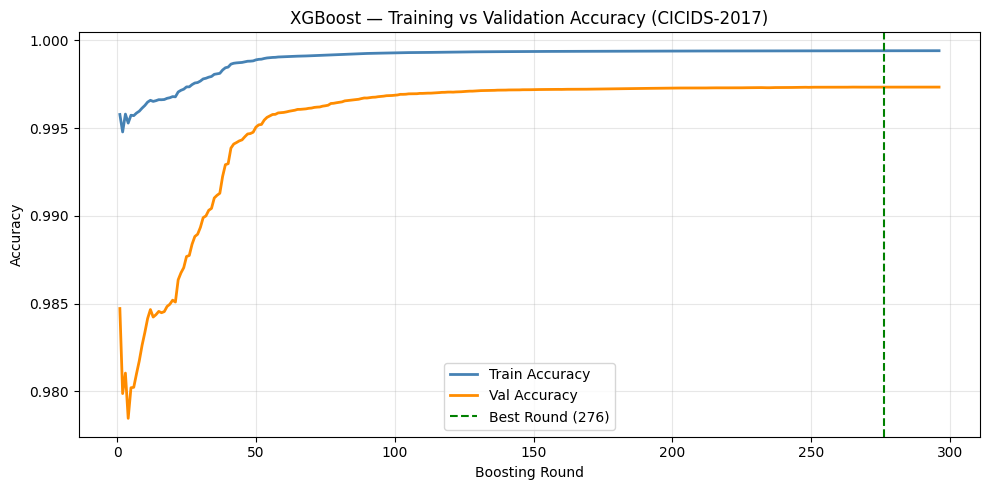

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(epochs_ran, train_acc, label='Train Accuracy', color='steelblue',  **STYLE)
plt.plot(epochs_ran, val_acc,   label='Val Accuracy',   color='darkorange', **STYLE)
plt.axvline(best_round + 1, color='green', linestyle='--', label=f'Best Round ({best_round+1})')
plt.title('XGBoost — Training vs Validation Accuracy (CICIDS-2017)')
plt.xlabel('Boosting Round'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('xgb_accuracy.png', dpi=150); plt.show()

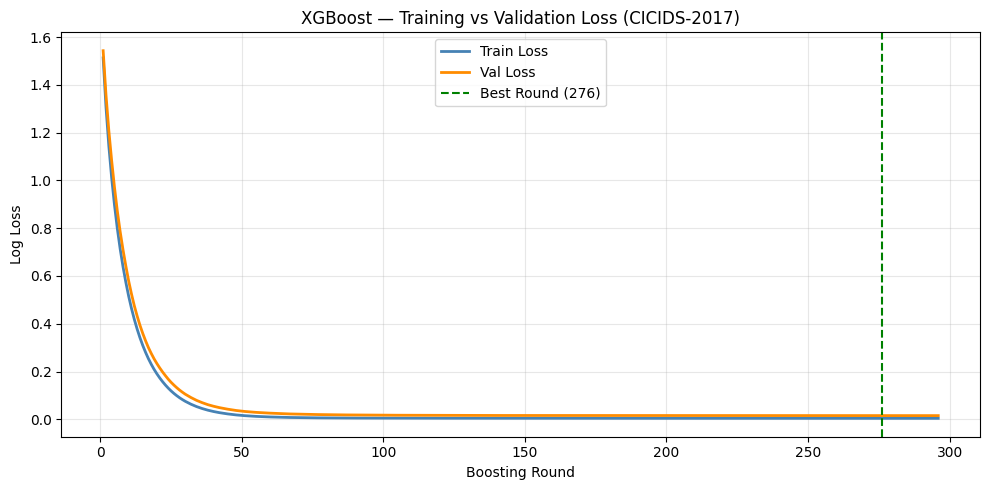

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(epochs_ran, train_loss, label='Train Loss', color='steelblue',  **STYLE)
plt.plot(epochs_ran, val_loss,   label='Val Loss',   color='darkorange', **STYLE)
plt.axvline(best_round + 1, color='green', linestyle='--', label=f'Best Round ({best_round+1})')
plt.title('XGBoost — Training vs Validation Loss (CICIDS-2017)')
plt.xlabel('Boosting Round'); plt.ylabel('Log Loss')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('xgb_loss.png', dpi=150); plt.show()

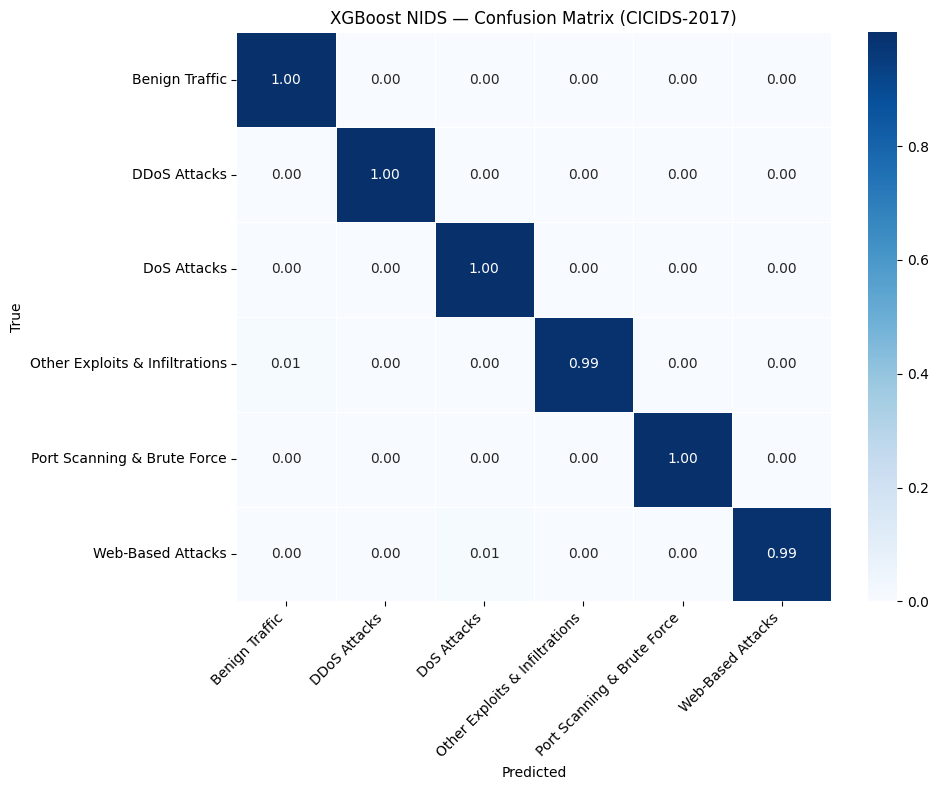

In [ ]:
cm = confusion_matrix(y_te, y_pred, normalize='true')
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=0.5)
plt.title('XGBoost NIDS — Confusion Matrix (CICIDS-2017)')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig('xgb_confusion_matrix.png', dpi=150); plt.show()

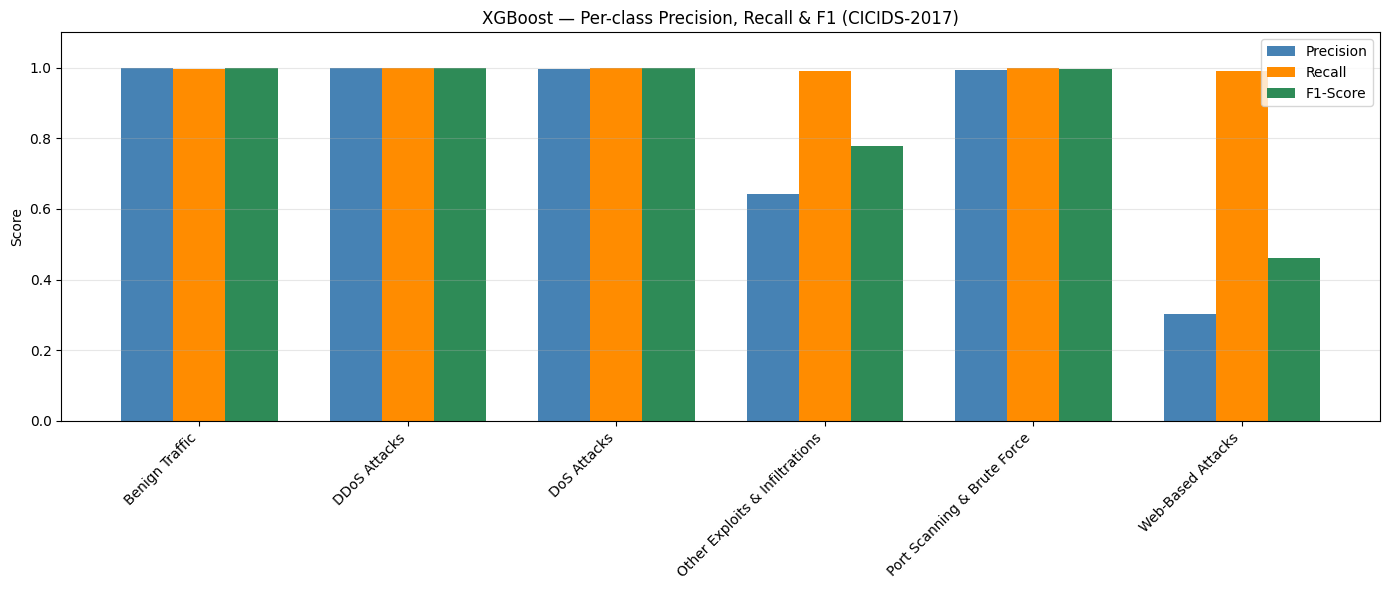

In [ ]:
import pandas as pd
report    = classification_report(y_te, y_pred,
                                   target_names=CLASS_NAMES,
                                   output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T.loc[CLASS_NAMES, ['precision', 'recall', 'f1-score']]

x      = np.arange(len(CLASS_NAMES))
width  = 0.25
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, report_df['precision'], width, label='Precision', color='steelblue')
ax.bar(x,         report_df['recall'],    width, label='Recall',    color='darkorange')
ax.bar(x + width, report_df['f1-score'],  width, label='F1-Score',  color='seagreen')
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_ylim(0, 1.1); ax.set_ylabel('Score'); ax.legend()
ax.set_title('XGBoost — Per-class Precision, Recall & F1 (CICIDS-2017)')
ax.grid(axis='y', alpha=0.3); plt.tight_layout()
plt.savefig('xgb_per_class_metrics.png', dpi=150); plt.show()

# Saving

In [ ]:
# ── Model ─────────────────────────────────────────────────────────────────────
xgb_model.save_model('xgb_cicids.json')
print("Model saved    → xgb_cicids.json ✅")

# ── Scaler & Label Encoder ────────────────────────────────────────────────────
joblib.dump(scaler, 'xgb_scaler.pkl')
joblib.dump(le,     'xgb_label_encoder.pkl')
print("Scaler saved   → xgb_scaler.pkl ✅")
print("LEncoder saved → xgb_label_encoder.pkl ✅")

# ── Metrics CSV ───────────────────────────────────────────────────────────────
metrics_df = pd.DataFrame([{
    'model'              : 'XGBoost',
    'accuracy'           : acc,
    'precision_weighted' : prec_w,
    'recall_weighted'    : rec_w,
    'f1_weighted'        : f1_w,
    'f1_macro'           : f1_macro,
    'best_round'         : best_round + 1,
}])
metrics_df.to_csv('xgb_metrics.csv', index=False)
print("Metrics saved  → xgb_metrics.csv ✅")
